## double well 1d

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES']='0'

import sys
sys.path.insert(0, os.path.abspath('..'))

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
import optax

import flax
import flax.linen as nn

from omegaconf import OmegaConf

from src.consistency_bridge import ConsistencyBridge

from src.models import ScoreMLP, ConservativeMLP
from src.plotting import plot_trajectories_1d, plot_trajectories_with_background_1d

## define reference process

In [2]:
a = jnp.sqrt(1.0)
v = 3.0

def double_well_potential_1d(x):
    first_term = v * (x**2 - a**2)**2
    return first_term.sum()

double_well_potential = double_well_potential_1d

def base_drift(x, t):
    # drift of the base process
    return -jax.grad(double_well_potential)(x)


sigma = 1.0 
d = 1

shape = (d,)

x_0 = jnp.array([a])
x_T = jnp.array([-a])

T = 1.0

## Train Consistency Bridge

In [ ]:
# model = ScoreMLP(
#     dim_hidden=(128, 128),
#     emb_dim_hidden=(64, 64),
#     activation=nn.gelu,
#     out_dim=d
# )

model = ConservativeMLP(
    dim_hidden=(128, 128),
    emb_dim_hidden=(64, 64),
    activation=nn.gelu,
)

bridge_config = {
        'base_drift': False,
        'guiding_type': 'brownian',
        'decay_coeff': False,
        'sampler': 'euler',
    }

bridge = ConsistencyBridge(
    shape=shape,
    x_0=x_0,
    x_T=x_T,
    base_drift_fn=base_drift,
    sigma_fn=sigma,
    model=model,
    bridge_config=bridge_config,
    T=T
)

Training: 100%|████████████████████████| 1000/1000 [00:50<00:00, 19.76step/s, loss=1.5802e+02, ema_grad_norm=1.1877e+01]


Training finished.


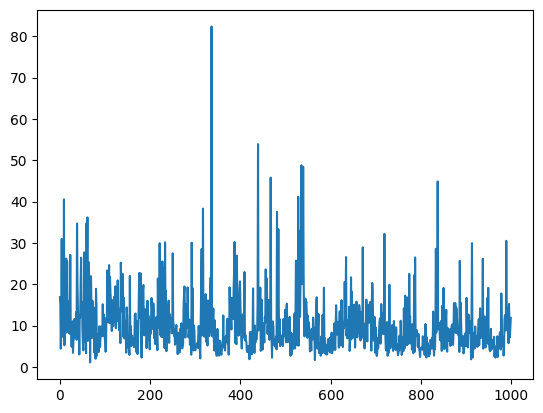

In [4]:
train_config = {
    'num_steps': 500,              # number of discretisation steps
    'num_outer_iterations': 1000, # number of outer iterations
    'num_inner_iterations': 1,      # number of inner iterations
    'traj_batch_size': 64,          # number of trajectories per outer iteration
    'train_batch_size': 4096,       # number of training samples per inner iteration
    'lr': 1e-3,           # learning rate
    'ema_rate': 1.0, # ema rate: 1.0 means no ema
    'grad_ema_rate': 1.0, #
    'jacobian_method': 'euler', 
    'beta_schedule': 'average', #'average', # 'average', 'beta', 'endpoint', 'next_step',
    'B_ratio': 0.9,
    'ckpt_freq': 100,          # frequency of checkpoints,
    'STL_adjustments': False, #True, 
}

key = jax.random.PRNGKey(0)
state, ema_params_lst, ema_grad_norms = bridge.train(key, train_config)

plt.plot(ema_grad_norms)

## make plots

In [ ]:
# plot them
n_y = 200
# Y range padded a bit beyond observed values to ensure nice margins
y_min = -1.5
y_max = 1.5
pad = 0.1 * max(1e-9, (y_max - y_min))
y = jnp.linspace(y_min - pad, y_max + pad, n_y)

# Time grid (x-axis is time steps 0..N-1)
N = train_config['num_steps'] + 1
t = jnp.linspace(0, T, N)

# Create meshgrid for plotting
X, Y = jnp.meshgrid(t, y, indexing='xy')
V_y = jax.vmap(double_well_potential_1d)(y)
Z = jnp.repeat(V_y[:, None], N, axis=1)  # same potential across time

background_data = {"X": X, "Y": Y, "Z": Z}

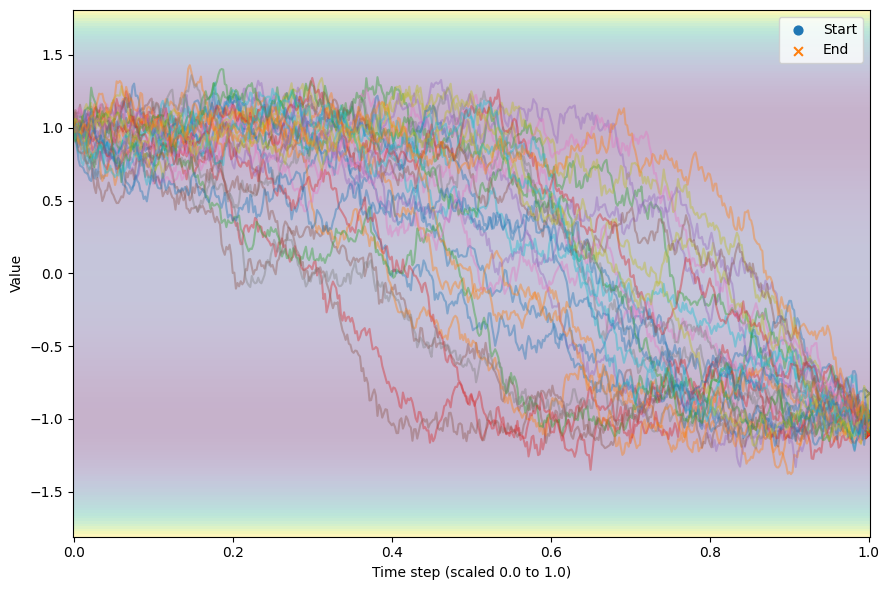

In [6]:
idx = -1 
ema_params = ema_params_lst[idx] 

num_steps = train_config['num_steps']
num_trajs = 32
sample_keys = jax.random.split(jax.random.PRNGKey(0), num_trajs)

x_traj, drift_traj, dB_t_traj = jax.vmap(
            bridge.sample_controlled_sde,
            in_axes=(0, None, None)
            )(sample_keys, ema_params, num_steps)

plot_trajectories_with_background_1d(x_traj, background_data, alpha=0.5)